# Binary Classification Using the Breast Cancer Dataset

Build and train a neural network for binary classification using a real medical dataset.

**Dataset source:**  
Breast Cancer Wisconsin (Diagnostic)  
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic  

---

## 1) Load the Dataset

Use:

`from sklearn.datasets import load_breast_cancer`

---

## 2) Split the Data

Split the dataset into training and test sets using:

`test_size = 0.2`

---

## 3) Build the Neural Network

Create a Sequential model with the following architecture:

Input layer: ?  
Hidden layer 1: 16 neurons, ReLU activation  
Hidden layer 2: 16 neurons, ReLU activation  
Output layer: 2 neurons, sigmoid activation  

---

## 4) Train the Model

Train for **50 epochs**.

Use **20% of training data for validation**.

Store the **history object**.

---

## 5) Plot Training Results

Create two plots:

### Loss vs Epoch
Plot training loss.  
Plot validation loss.

### Accuracy vs Epoch
Plot training accuracy.  
Plot validation accuracy.

---

## 6) Reflection Questions

Is the model **overfitting**? Explain why or why not.

What is the **final test accuracy**?

What happens if you **increase the number of neurons**?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
#https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape:", X.shape)
print("Classes:", np.unique(y))

Shape: (569, 30)
Classes: [0 1]


In [ ]:
import pandas as pd

df = pd.DataFrame(X, columns=data.feature_names)

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [ ]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [ ]:
y_train = to_categorical(y_train, 2)
y_test  = to_categorical(y_test, 2)

In [ ]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(16, activation='relu'),
    Dense(2, activation='sigmoid')   # 2 outputs + sigmoid
])

model.compile(
    optimizer='sgd',
    loss='mse',
    metrics=['accuracy']
)
# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802 (3.13 KB)

 Trainable params: 802 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

Total params = total number of learnable weights and biases in the network.

Each of the 16 neurons connects to 30 inputs.

Weights:

30×16=480


Biases:

16


Total:

480+16=496


Parameters=(inputs×neurons)+neurons

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)



The dataset was first split into 80% training and 20% test.

Then, 20% of the training set was used for validation.

This results in:

64% for actual training

16% for validation

20% for final testing



In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9522 - loss: 0.0686 
Test accuracy: 0.9561403393745422


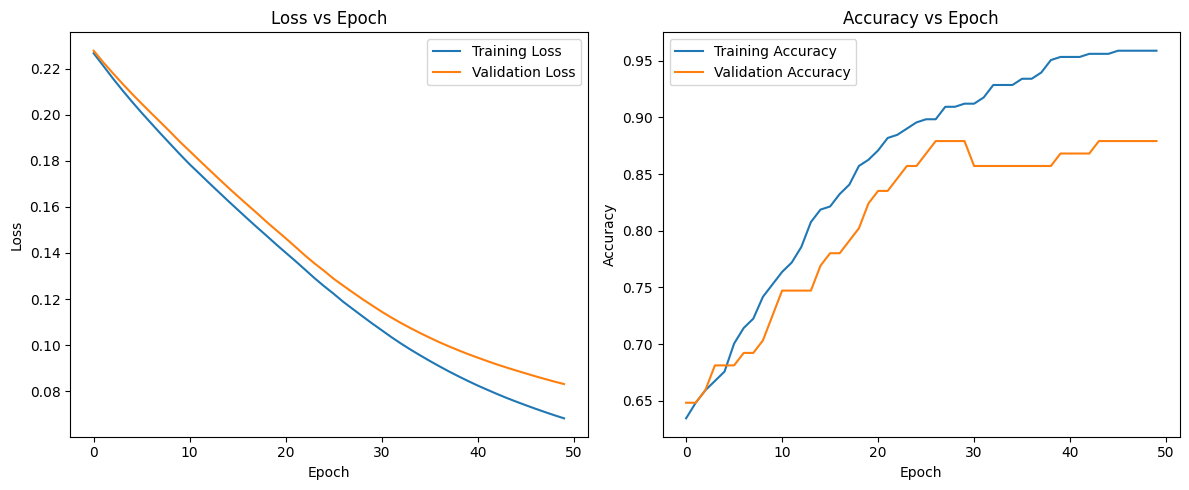

In [ ]:
plt.figure(figsize=(12,5))

# ----- Loss Plot -----
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# ----- Accuracy Plot -----
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()